## Financial Sentiment Analysis
 <p>
 WMG9B7-15 - Artificial Intelligence & Deep Learning<br>
 u5696284<br>
 A sentiment analysis using Twitter Financial News dataset.
 <p>

### Phase 0: Setup & Environment

In [72]:
%pip install ipykernel numpy pandas matplotlib scikit-learn transformers datasets evaluate torch ipywidgets -q

Note: you may need to restart the kernel to use updated packages.


In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch
from datasets import load_dataset
import re
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed_all(SEED)

### Phase 1: Data Loading & Exploration

In [75]:
ds = load_dataset("zeroshot/twitter-financial-news-sentiment")

In [76]:
print(ds)
# Splitting ds into training and testing dataset
train_data = ds['train']
test_data = ds['validation']

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9543
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2388
    })
})


In [114]:
LABEL_MAP = {0:'Bearish', 1:'Bullish', 2:'Neutral'}

**Label Mapping:**
- 0: Bearish
- 1: Bullish
- 2: Neutral

In [77]:
# Converting train and test python dict to pandas dataframe
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

In [78]:
print(train_df.shape)
print(test_df.shape)

(9543, 2)
(2388, 2)


In [79]:
train_df.head()

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


In [80]:

for label_id, label_name in LABEL_MAP.items():
    idx = train_df[train_df['label'] == label_id].index[50]
    print(f"\nLabel {label_id} ({label_name}) at index {idx}")
    print(train_df.loc[idx, "text"])


Label 0 (Bearish) at index 50
Canada Goose stock price target cut to $50 from $65 at CFRA

Label 1 (Bullish) at index 176
Analysts See 18% Gains Ahead For The Holdings Of The First Trust Dow Jones Internet Index Fund ETF

Label 2 (Neutral) at index 446
Bank of Israel expands its crisis QE with $13.6 billion in bond buying https://t.co/xEMWn1vjAO


In [81]:
train_df.dtypes # Checking type of data

text       str
label    int64
dtype: object

In [82]:
train_df['text'].duplicated().sum()  # Returns number of duplicate rows

np.int64(0)

In [83]:
train_df.isna().sum() # Checking for missing values

text     0
label    0
dtype: int64

In [84]:
# Checking class distribution
counts = train_df["label"].value_counts().rename(index=LABEL_MAP)
pct = train_df["label"].value_counts(normalize=True).mul(100).rename(index=LABEL_MAP)

summary = pd.DataFrame({"count": counts, "percentage": pct})
print(summary)

         count  percentage
label                     
Neutral   6178   64.738552
Bullish   1923   20.150896
Bearish   1442   15.110552


<p>Class imbalance identified. It can be observed that ~65% of the dataset is made up of neutral statements while the Bullish and Bearish statements are only 20% and 15% respectively. This could result in a misleading accuracy where the model accurately predicts the majority class to achieve artificially high scores despite failing to identify the minority class. In this case, precision and recall are better metrics to know how well the model identifies the minority classes but a better option would be F1 Score as it is a harmonic mean of both Precision and Recall and we would specifically use Macro F1 Score as it treats all classes equally, making it superior for imbalanced datasets where minority class performance matters.<br>For model training, can consider class_weight = 'balanced' for the baseline and weighted loss for FinBERT.</p>

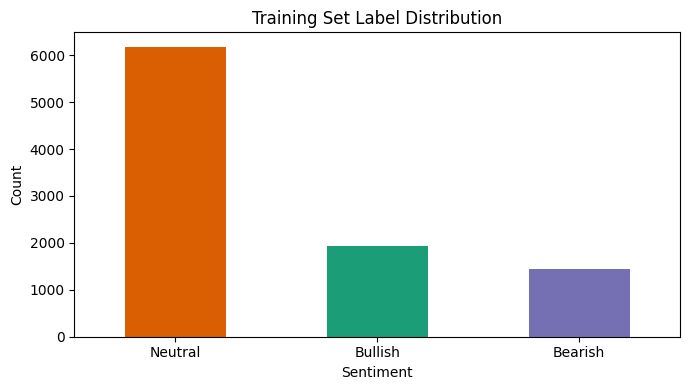

In [85]:
# Plot: Label distribution
label_counts = train_df["label"].map(LABEL_MAP).value_counts()

plt.figure(figsize=(7, 4))
label_counts.plot(kind="bar", color=["#d95f02", "#1b9e77", "#7570b3"])
plt.title("Training Set Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Phase 2: TF-IDF + Logistic Regression (Baseline)

In [86]:
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

In [87]:
# Text Cleaning using RegEx
# Normalize tweet text for modeling by removing cashtags/URLs/mentions, stripping symbols,
# and lowercasing so the sentiment model learns from consistent headline words.

def clean_tweet_headline(text: str) -> str:
    text = re.sub(r'\$\w+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

train_df['text'] = train_df['text'].apply(clean_tweet_headline)
test_df['text'] = test_df['text'].apply(clean_tweet_headline)

In [88]:
# Sanity Test
for label_id, label_name in LABEL_MAP.items():
    idx = train_df[train_df['label'] == label_id].index[50]
    print(f"\nLabel {label_id} ({label_name}) at index {idx}")
    print(train_df.loc[idx, "text"])


Label 0 (Bearish) at index 50
canada goose stock price target cut to  from  at cfra

Label 1 (Bullish) at index 176
analysts see  gains ahead for the holdings of the first trust dow jones internet index fund etf

Label 2 (Neutral) at index 446
bank of israel expands its crisis qe with  billion in bond buying


<p>The cashtags, URLs, and mentions have been removed. Lowercase has been applied. Punctuation stripped.<br>Limitation: the cleaning function also removes any numbers mentioned as percentages which is why you see gaps like "cut to  from  at"</p>

In [89]:
# Detected Duplicates after Cleaning
print('Duplicates in Training Data post-cleaning:',train_df['text'].duplicated().sum())
print('Duplicates in Test Data post-cleaning:',test_df['text'].duplicated().sum())

Duplicates in Training Data post-cleaning: 260
Duplicates in Test Data post-cleaning: 25


In [90]:
train_df[train_df.duplicated(subset=['text'], keep=False)].sort_values('text').head(20) # Also Detected empty rows in 'text' column

,text,label
3943,,2
3948,,2
3949,,2
3950,,2
4681,,2
4682,,2
4683,,2
8160,,2
8224,,2
8237,,2


In [91]:
test_df[test_df.duplicated(subset=['text'], keep=False)].sort_values('text').head(20) # Also Detected empty rows in 'text' column

,text,label
2034,,2
2061,,2
2062,,2
2064,,2
293,allergan form allergan stock marketscreener,2
294,allergan form allergan stock marketscreener,2
512,b riley offers of senior notes,2
521,b riley offers of senior notes,2
2301,canopy growth premarket on new cannabis licen...,1
2340,canopy growth premarket on new cannabis licen...,1


In [92]:
print('Empty rows in training data text column:',(train_df['text']== '').sum())
print('Empty rows in test data text column:',(test_df['text']== '').sum())

Empty rows in training data text column: 17
Empty rows in test data text column: 4


In [93]:
# Drop duplicates and empty rows in text column
train_df.replace('', pd.NA, inplace=True)
train_df.dropna(inplace=True)
test_df.replace('', pd.NA, inplace=True)
test_df.dropna(inplace=True)

train_df = train_df.drop_duplicates(subset=['text'], keep='first')
test_df = test_df.drop_duplicates(subset=['text'], keep='first')

In [94]:
# Helper Function to verify
def verify_cols(df, col):
    # Check for empty rows
    empty = (df[col] == '').sum()
    if empty == 0:
        print(f'No empty rows found in {col} column.')
    else:
        print(f'Empty rows in {col} column: {empty}')

    # Check for NA values
    na = (df[col].isna().sum())
    if na == 0:
        print(f'No missing values in {col} column.')
    else:
        print(f'Missing Values in {col} column: {na}')

    # Check for Duplicates
    dup = df[col].duplicated().sum()
    if dup == 0:
        print(f'No duplicate values in {col} column.')
    else:
        print(f'Duplicate Values in {col} column: {dup}')
    print('\n')      

verify_cols(train_df, 'text')         
verify_cols(test_df, 'text')                  

No empty rows found in text column.
No missing values in text column.
No duplicate values in text column.


No empty rows found in text column.
No missing values in text column.
No duplicate values in text column.




Detected empty and duplicate rows in the text column as an effect of text cleaning, in both training and test data.
<br>Dropped 17 empty rows from training data and 4 from test data - Tweets became empty after cleaning and had no semantic meaning 
<br>Dropped 260 duplicate rows from training data and 25 from test data - Distinct Tweets became identical and redundant after removal of Cashtags and URLs and had to be dropped to avoid frequency inflation of classes. 

In [95]:
# TF-IDF + Logistic Regression Pipeline
tfidf_lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 1), stop_words='english')),
    ('logreg', LogisticRegression(class_weight='balanced', max_iter=1000))
])

In [96]:
# Train pipeline and generate predictions
tfidf_lr_pipeline.fit(train_df['text'], train_df['label'])
pred = tfidf_lr_pipeline.predict(test_df['text'])

In [97]:
print(classification_report(test_df['label'], pred, target_names=list(LABEL_MAP.values())))

              precision    recall  f1-score   support

     Bearish       0.57      0.69      0.63       344
     Bullish       0.69      0.75      0.72       472
     Neutral       0.90      0.83      0.87      1546

    accuracy                           0.80      2362
   macro avg       0.72      0.76      0.74      2362
weighted avg       0.81      0.80      0.80      2362



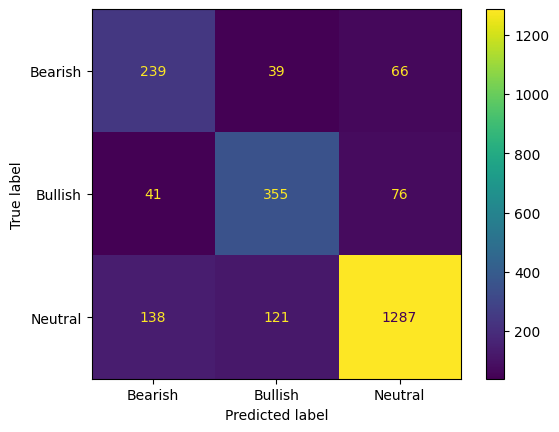

In [98]:
cm = confusion_matrix(test_df['label'], pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bearish','Bullish', 'Neutral'])
disp.plot()

### Result Interpretation
A naive classifier that always predicts the majority class (Neutral) would achieve high accuracy but near-zero macro F1, since it would fail entirely on Bearish and Bullish. The baseline macro F1 of 0.74 therefore represents genuine learning across all three classes, but remains insufficient for reliable financial use given the minority class performance.

Neutral class scores higher not only because it has the highest number of examples which allows the model to generalize better to the particular class but also because the TF-IDF vectorizer we use ignores word order and contextual meaning due to its bag-of-words nature which penalizes bullish and bearish statements as they require contextual meaning to be interpreted correctly compared to the majority class which is neutral in nature and does not require contextual meaning.

This is confirmed by the confusion matrix. The model misclassifies  39 bearish statements as bullish and 66 as neutral, telling traders that a stock will rise or hold when it will fall. Similarly, 41 bullish statements are misclassified as bearish and 76 as neutral causing traders to either sell appreciating stocks or miss investment opportunities entirely. Both failure modes carry significant financial consequences and are equally dangerous in practice.

Hence, the inability to capture contextual meaning and compounded by class imbalance motivate the use of FinBERT in the next phase, a specialized BERT-based NLP model pre-trained on financial data that explicitly models word order, context, and domain-specific semantics.

### Phase 3: FinBERT

In [99]:
tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')

lengths = tokenizer(
    list(train_df['text']),
    truncation=False,
    return_length=True
)['length']

len_arr = np.array(lengths)
per = np.percentile(len_arr, (95, 99, 100))
print(f'95th Percentile: {per[0]}\n99th Percentile: {per[1]}\n100th Percentile: {per[2]}',)

95th Percentile: 24.0
99th Percentile: 27.0
100th Percentile: 65.0


To decide on a value for max_length, we run the tokenizer on the training data without the max_length cap and inspect the 95th, 99th and 100th percentile of token lengths.<br>95% of the tweets are 24 tokens or lower which reflects the short tweets format of the Financial Twitter dataset. At max, tweets can be 65 tokens. Also, BERT tokenisers add two special tokens to every input, [CLS] at the start and [SEP] at the end.<br>With that in mind, setting max_length=67 (65+2) would mean that no tweets in the dataset would get cut short. Hence, max_length=67

In [100]:
class FinBERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=67):
        self.encodings = tokenizer(
            list(texts), max_length=max_length, padding = 'max_length', truncation=True
            )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item    

In [101]:
# Initialise FinBERTDataset class for both training and test dataset
train_dataset = FinBERTDataset(list(train_df['text']),list(train_df['label']), tokenizer)
test_dataset = FinBERTDataset(list(test_df['text']), list(test_df['label']), tokenizer)

In [102]:
# Defining Dataloaders for both set of data
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [103]:
# Loading the FinBERT model
model = AutoModelForSequenceClassification.from_pretrained(
    'ProsusAI/finbert',
    num_labels = 3
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [104]:
#Hyperparameters
learning_rate = 2e-5

#compute class weight
class_weight = compute_class_weight(class_weight='balanced', classes=np.unique(train_df['label']), y=train_df['label'])

In [105]:
# Initialize AdamW optimizer and set up loss function
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(weight = torch.tensor(class_weight, dtype=torch.float))

In [108]:
# Learning Rate Scheduler
EPOCHS = 4
total_steps = len(train_dataloader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

In [109]:
# Training Loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model.to(device)
criterion = criterion.to(device)  # move loss weights to same device

for epoch in range(EPOCHS):
    model.train()  # sets model to training mode (enables dropout etc.)
    total_loss = 0
    
    for batch in train_dataloader:
        # move batch to GPU/CPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()  # clear gradients from previous step
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)  # forward pass
        
        loss = criterion(outputs.logits, labels)  # compute loss
        
        loss.backward()  # backpropagate
        
        optimizer.step()  # update weights

        scheduler.step() # decays learning rate
        
        total_loss += loss.item()
    
    print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(train_dataloader):.4f}')

Epoch 1/4, Loss: 0.7648
Epoch 2/4, Loss: 0.4118
Epoch 3/4, Loss: 0.2354
Epoch 4/4, Loss: 0.1521


In [110]:
# Save Model after training
model.save_pretrained('finbert_finetuned')
tokenizer.save_pretrained('finbert_finetuned')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('finbert_finetuned\\tokenizer_config.json',
 'finbert_finetuned\\tokenizer.json')

In [111]:
# Reload Model after Saving
model = AutoModelForSequenceClassification.from_pretrained('finbert_finetuned')
model.to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [112]:
# Evaluation Loop
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['Bearish', 'Bullish', 'Neutral']))

              precision    recall  f1-score   support

     Bearish       0.69      0.83      0.75       344
     Bullish       0.78      0.80      0.79       472
     Neutral       0.93      0.88      0.90      1546

    accuracy                           0.86      2362
   macro avg       0.80      0.84      0.82      2362
weighted avg       0.86      0.86      0.86      2362



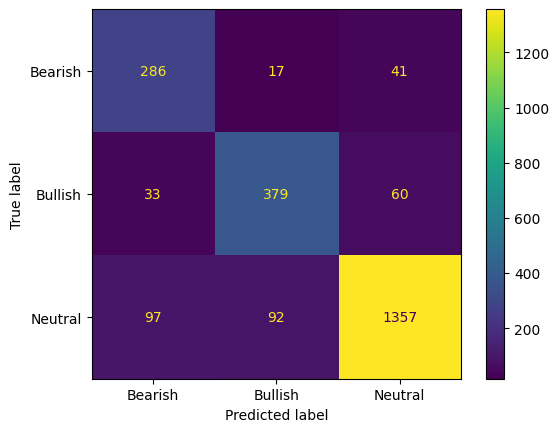

In [113]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bearish','Bullish', 'Neutral'])
disp.plot()

### Result Interpretation
After training the FinBERT model on the Financial Tweets dataset, significant improvement has been observed relative to the results of the baseline model.The overall Macro F1 score has increased from 0.74 to 0.82. Next, the recall of Bearish has jumped from 0.69 to 0.83, and for Bullish,a meaningful increase of 0.75 to 0.80, suggesting that both minority classes showed significant improvement. This means that the model's generalization on the minority classes has improved and misclassification of them is reduced.The Neutral class remains strong with slight improvement in F1-score(0.87 to 0.90).<br>This is confirmed by the confusion matrix. The misclassification of Bearish class for Bullish and Neutral classes dropped significantly (from 39+66 to 17+41). The same can be said for Bullish class also(from 41+76 to 33+60).<br>Overall, the use of FinBERT model has significantly improved the reliability of the model for real world financial practices. Particularly, with the improvement in Bearish class, the model is able to predict better about which stocks are going to fall so traders can sell them early on and avoid the risk of losing their investment.